##### ARTI 560 - Computer Vision

## Visual Representations with DINOv2 - Exercise

### Exercise 1: Unsupervised Clustering

In this exercise, you will use the `KMeans` algorithm from sklearn to group 20 images from the Oxford Pet dataset into 2 clusters (Cats vs. Dogs) based purely on their CLS tokens.

Instructions:

1.  Extract the 384-dimensional [CLS] tokens from 20 images of the Oxford-IIIT Pet dataset. Ensure your selection includes a mix of both cats and dogs.

2. Apply K-Means Clustering ($n=2$) to group the vectors based on mathematical similarity rather than provided labels.

3. Compare the predicted clusters against ground-truth labels.

In [1]:
!pip install transformers torchvision scikit-learn -q

In [8]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision.datasets import OxfordIIITPet
from torchvision import transforms
from transformers import AutoImageProcessor, AutoModel
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score

In [10]:
MODEL_ID = "facebook/dinov2-small"
device   = "cuda" if torch.cuda.is_available() else "cpu"

processor = AutoImageProcessor.from_pretrained(MODEL_ID)
model     = AutoModel.from_pretrained(MODEL_ID).to(device)
model.eval()
print(f"Model {MODEL_ID} loaded on {device}")

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Model facebook/dinov2-small loaded on cuda


In [11]:
dataset = OxfordIIITPet(
    root="./data",
    split="test",
    download=True,
    transform=None
)

In [12]:
cat_indices = [i for i, (_, lbl) in enumerate(dataset) if lbl  < 25][:10]
dog_indices = [i for i, (_, lbl) in enumerate(dataset) if lbl >= 25][:10]
selected_indices = cat_indices + dog_indices

In [13]:
#Ground truth
#binary label >> 0 = cat, 1 = dog
ground_truth = [0] * 10 + [1] * 10

In [15]:
@torch.no_grad()
def get_cls_token(pil_image):
    inputs = processor(images=pil_image.convert("RGB"), return_tensors="pt").to(device)
    outputs = model(**inputs)
    cls = outputs.last_hidden_state[:, 0]
    return F.normalize(cls, p=2, dim=1).squeeze().cpu().numpy()

cls_tokens = np.stack([get_cls_token(dataset[i][0]) for i in selected_indices])
print(f"Extracted CLS tokens: {cls_tokens.shape}")

Extracted CLS tokens: (20, 384)


In [16]:
kmeans = KMeans(n_clusters=2, n_init=10, random_state=42)
cluster_labels = kmeans.fit_predict(cls_tokens)

In [17]:
acc_direct  = accuracy_score(ground_truth, cluster_labels)
acc_flipped = accuracy_score(ground_truth, 1 - cluster_labels)
#KMeans label 0/1 may be swapped
if acc_flipped > acc_direct:
    cluster_labels = 1 - cluster_labels
    acc = acc_flipped
else:
    acc = acc_direct

In [18]:
print("\nPredicted clusters (0 : Cat, 1 : Dog):")
print(cluster_labels)
print("\nGround-truth labels (0 : Cat, 1 : Dog):")
print(np.array(ground_truth))
print(f"\nClustering accuracy: {acc * 100:.1f}%")


Predicted clusters (0 : Cat, 1 : Dog):
[0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1]

Ground-truth labels (0 : Cat, 1 : Dog):
[0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1]

Clustering accuracy: 100.0%


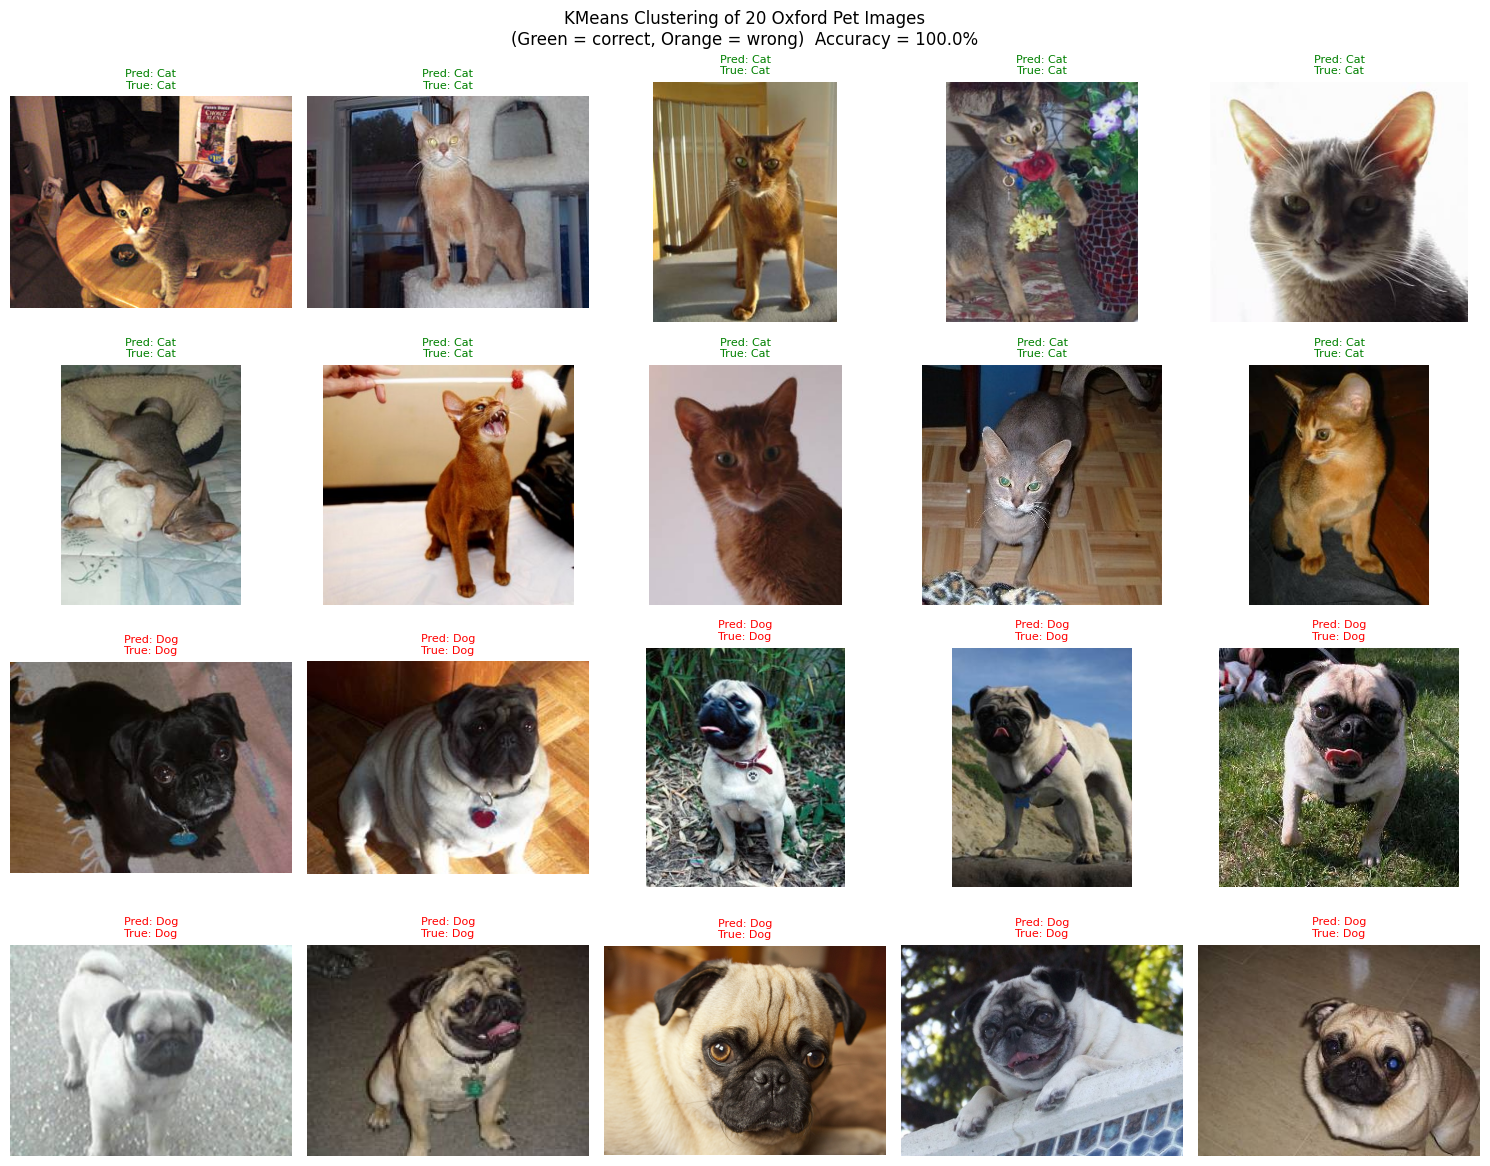

In [19]:
fig, axes = plt.subplots(4, 5, figsize=(15, 12))
axes = axes.flatten()
labels_text = {0: "Cat", 1: "Dog"}
colours     = {0: "green", 1: "red"}

for ax, idx, pred, true in zip(axes, selected_indices, cluster_labels, ground_truth):
    img = dataset[idx][0]
    ax.imshow(img)
    correct = (pred == true)
    colour  = colours[pred] if correct else "orange"
    ax.set_title(
        f"Pred: {labels_text[pred]}\nTrue: {labels_text[true]}",
        color=colour, fontsize=8
    )
    ax.axis("off")

plt.suptitle(
    f"KMeans Clustering of 20 Oxford Pet Images\n"
    f"(Green = correct, Orange = wrong)  Accuracy = {acc*100:.1f}%",
    fontsize=12
)
plt.tight_layout()
plt.show()

### Exercise 2: Image Classification with DINOv2

In this exercise you'll use a DINOv2 model with a pre-trained linear head to classify an image. You will observe how the model maps visual features to specific ImageNet-1k categories.

Instructions:
1. For this exercise, you must use the following Model ID. This specific checkpoint includes the necessary classification head trained on ImageNet-1k:

    Model ID: `facebook/dinov2-small-imagenet1k-1-layer`

2. Find an image online to make the inference. To ensure the model has a fair chance of success, the image should belong to one of the ImageNet-1k classes (e.g., a Golden Retriever, a grand piano, a school bus, or a coffee mug).

In [20]:
import requests
import torch
from PIL import Image
from io import BytesIO
from transformers import AutoImageProcessor, AutoModelForImageClassification

In [21]:
MODEL_ID = "facebook/dinov2-small-imagenet1k-1-layer"
device   = "cuda" if torch.cuda.is_available() else "cpu"

processor = AutoImageProcessor.from_pretrained(MODEL_ID)
model     = AutoModelForImageClassification.from_pretrained(MODEL_ID).to(device)
model.eval()
print(f"Model {MODEL_ID} loaded on {device}")

preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/91.3M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/225 [00:00<?, ?it/s]

Model facebook/dinov2-small-imagenet1k-1-layer loaded on cuda


In [24]:
IMAGE_URL = (
    "https://images.dog.ceo/breeds/retriever-golden/n02099601_3004.jpg"
)

response = requests.get(IMAGE_URL, timeout=10)
img = Image.open(BytesIO(response.content)).convert("RGB")

In [25]:
inputs = processor(images = img, return_tensors = "pt").to(device)

with torch.no_grad():
    logits = model(**inputs).logits  #the shape (1, 1000)

#Top 5 predictions
probs = logits.softmax(dim=-1)[0]
top5_idx = probs.topk(5).indices.tolist()
top5_prb = probs.topk(5).values.tolist()

print("\nTop 5 ImageNet-1k predictions:")
for rank, (idx, prob) in enumerate(zip(top5_idx, top5_prb), 1):
    label = model.config.id2label[idx]
    print(f"  {rank}. {label:<40s}  {prob*100:6.2f}%")


Top 5 ImageNet-1k predictions:
  1. golden retriever                           97.41%
  2. Labrador retriever                          0.37%
  3. English setter                              0.34%
  4. otterhound, otter hound                     0.31%
  5. tennis ball                                 0.22%


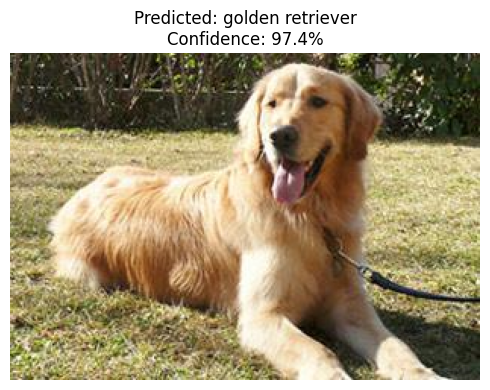

In [26]:
import matplotlib.pyplot as plt

top1_label = model.config.id2label[top5_idx[0]]
top1_conf  = top5_prb[0]

plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.title(f"Predicted: {top1_label}\nConfidence: {top1_conf*100:.1f}%", fontsize=12)
plt.axis("off")
plt.tight_layout()
plt.show()